# Qubit-Drive-GRAPE: Experimental Campaign

**A GRAPE-optimized universal gate set on a cat-code logical qubit in a transmon-cavity system**

Author: Ian Dong
Date: 2026-07-22

Primary reference: Heeres, R. W., Reinhold, P., Ofek, N., *et al.* "Implementing a
universal gate set on a logical qubit encoded in an oscillator." *Nature
Communications* **8**, 94 (2017). [doi:10.1038/s41467-017-00045-1](https://www.nature.com/articles/s41467-017-00045-1)

## Abstract

This notebook is the complete, reproducible experimental record for the
Qubit-Drive-GRAPE project: GRAPE (gradient ascent pulse engineering) control
of a dispersively-coupled transmon-cavity system, realizing an even-parity
cat-code logical qubit and a universal single-qubit gate set on it (encode,
decode, X, Y, Z, H, T, I). The key technical contribution demonstrated here is
the resolution of a *truncation-wall exploitation* failure mode: naive
multi-truncation training converges to pulses that look excellent at the
trained cavity dimension but collapse in fidelity just beyond it, because the
optimizer learns to reflect population off the artificial edge of the
truncated Hilbert space. We show that averaging fidelity across several
truncations *and* penalizing their pairwise discrepancy (Heeres et al.,
Supplementary Eqs. 23-24), recomputed fresh at every iteration and combined
with a cold start, restores fidelity that is flat from well below to well
above the training truncation. Every pulse produced here is independently
cross-checked with an unrelated QuTiP `sesolve` propagator, not just
grape_core's own hand-rolled integrator.

## Table of contents

0. Title & metadata (this section)
1. [Setup & reproducibility](#section-1)
2. [System definition & Hamiltonian sanity checks](#section-2)
3. [Cat-code definition & ideal state verification](#section-3)
4. [Experimental design: the truncation-wall problem](#section-4)
5. [Full logical gate-set campaign](#section-5)
6. [Comprehensive validation suite](#section-6)
7. [Pulse characterization](#section-7)
8. [Wigner tomography of key operations](#section-8)


<a id="section-1"></a>
## 1. Setup & Reproducibility

*Master switch, imports, hard-coded physical/optimization parameters, and
small helper utilities used throughout the notebook.*


In [1]:
# ============================================================
# MASTER SWITCH
# ============================================================
# False (default): Section 5 loads the existing, already-validated
#                   production pulses from pulses/ -- every downstream
#                   analysis section (6-8) runs on them. Fast, reproducible,
#                   nothing on disk is overwritten.
# True            : Section 5 re-optimizes all 8 logical gates from a cold
#                   start and OVERWRITES pulses/u_<gate>_main.npy.
#                   This is a long run (8 gates x 3 training truncations x
#                   L-BFGS-B with maxiter=PRODUCTION_MAXITER, see Section 1
#                   below) -- only flip this if you intend to regenerate the
#                   production pulse set.
RUN_OPTIMIZATION = False

In [2]:
# ============================================================
# Imports
# ============================================================
import os
import time
import json
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import joblib

try:
    import qutip
    QUTIP_AVAILABLE = True
except ImportError:
    QUTIP_AVAILABLE = False

# --- Project modules (all physics/optimization/analysis is reused, not
#     reimplemented, from the existing project files) ---
from core.grape_core import (
    two_pi, make_ops, make_hamiltonian, basis_state, step_data,
    fidelity_multi_state, fidelity_grad,
)
from core.optimizer import optimize_multi_state_pulse
from core.fourier_cutoff import project_bandlimit, out_of_band_energy_fraction, check_projection_properties
from core.cat_code import (
    get_logical_cat_states, embed_in_joint_space, get_encode_targets,
    get_encode_state_pairs, get_decode_state_pairs,
    get_logical_X_state_pairs, get_logical_Y_state_pairs, get_logical_Z_state_pairs,
    get_logical_H_state_pairs, get_logical_T_state_pairs, get_identity_state_pairs,
    validate_pulse_truncations, verify_cat_states,
)
from core.compare_pulses import get_g6_state_pairs, pulse_shape_metrics
from visualization.pulse_viz import plot_pulse_waveforms, plot_pulse_spectrum, analyze_pulse, plot_photon_trajectory
from visualization.wigner_viz import (
    compute_wigner, plot_wigner, plot_wigner_cat, plot_wigner_from_pulse,
    get_initial_joint_state, extract_cavity_state, propagate_pulse as wigner_propagate_pulse,
)
from validation.validate_logical_gates import (
    tier1_fidelity_robustness, tier2_logical_action_and_leakage,
    tier3_gate_algebra, tier4_enc_gate_dec_pipeline, GATE_PULSE_MAP,
)
from QuTip.qutip_validate import validate_pulse as qutip_cross_check_pulse

In [3]:
# ============================================================
# Library versions (for reproducibility)
# ============================================================
print(f"Python      : {platform.python_version()}")
print(f"numpy       : {np.__version__}")
print(f"scipy       : {scipy.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"joblib      : {joblib.__version__}")
print(f"qutip       : {qutip.__version__ if QUTIP_AVAILABLE else 'not installed'}")

Python      : 3.9.6
numpy       : 2.0.2
scipy       : 1.13.1
matplotlib  : 3.9.4
pandas      : 2.3.3
joblib      : 1.5.3
qutip       : 5.0.4


In [4]:
# ============================================================
# Physical parameters -- must match Heeres et al. 2017 / grape_core.py / README
# ============================================================
PHYSICAL_PARAMS = dict(
    chi_MHz=-2.194,          # dispersive shift chi
    Kerr_MHz=-0.0037,        # cavity self-Kerr
    chip_MHz=-0.019,         # second-order dispersive shift chi'
    alpha_MHz=-236.0,        # transmon anharmonicity
    alpha_cat=np.sqrt(3.0),  # cat-code coherent-state amplitude
    dt_us=0.002,             # time step (2 ns)
    N_steps=550,             # pulse length (~1.1 us total duration)
    n_t=3,                   # transmon levels (3rd level needed for leakage/anharmonicity)
)

DT = PHYSICAL_PARAMS["dt_us"]
N_STEPS = PHYSICAL_PARAMS["N_steps"]
N_T = PHYSICAL_PARAMS["n_t"]
ALPHA_CAT = PHYSICAL_PARAMS["alpha_cat"]

# ============================================================
# Final cold-start optimization recipe (used consistently from Section 5
# onward). Values match the repo's actual production recipe (see
# _scratch_main_batch.py / README "Truncation convergence and
# wall exploitation") rather than round placeholder numbers.
# ============================================================
OPTIMIZATION_RECIPE = dict(
    trunc_list=[22, 24, 26],
    penalties={"deriv": 1e-5, "boundary": 2e-5, "amp": 8e-5, "amp_max": 40.0, "disc": 0.5},
    warm_start=None,              # cold start: smooth low-pass random init, NOT a previous pulse
    cav_band=(-27.0, 27.0),
    tra_band=(-33.0, 33.0),
    hard_amp_limit=40.0,
    n_jobs=3,
)
# The pulses already saved under pulses/u_*_main.npy were
# produced with maxiter=400. We budget more here for a from-scratch run.
PRODUCTION_MAXITER = 1500

for k, v in PHYSICAL_PARAMS.items():
    print(f"{k:12s} = {v}")
print()
for k, v in OPTIMIZATION_RECIPE.items():
    print(f"{k:12s} = {v}")
print(f"{'maxiter':12s} = {PRODUCTION_MAXITER}")

chi_MHz      = -2.194
Kerr_MHz     = -0.0037
chip_MHz     = -0.019
alpha_MHz    = -236.0
alpha_cat    = 1.7320508075688772
dt_us        = 0.002
N_steps      = 550
n_t          = 3

trunc_list   = [22, 24, 26]
penalties    = {'deriv': 1e-05, 'boundary': 2e-05, 'amp': 8e-05, 'amp_max': 40.0, 'disc': 0.5}
warm_start   = None
cav_band     = (-27.0, 27.0)
tra_band     = (-33.0, 33.0)
hard_amp_limit = 40.0
n_jobs       = 3
maxiter      = 1500


In [5]:
# ============================================================
# Reproducibility: seed + output directories + small helper utilities
# ============================================================
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

PULSE_DIR = "pulses"
FIG_DIR = "figures"
TABLE_DIR = "tables"
RESULTS_DIR = "results"
WIGNER_DIR = "wigner"  # existing repo convention for Wigner-function figures


def ensure_dirs(*dirs):
    """Create output directories if they do not already exist."""
    for d in dirs:
        os.makedirs(d, exist_ok=True)


ensure_dirs(PULSE_DIR, FIG_DIR, TABLE_DIR, RESULTS_DIR, WIGNER_DIR)


def load_pulse_with_metadata(path, dt=DT):
    """Load a saved (N,4) control pulse and attach basic shape metrics."""
    u = np.load(path)
    meta = pulse_shape_metrics(u, dt=dt)
    meta["path"] = path
    return u, meta


def savefig_png_pdf(fig, path_stem):
    """Save a matplotlib figure as both PNG and PDF under the same filename stem."""
    fig.savefig(f"{path_stem}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{path_stem}.pdf", bbox_inches="tight")
    print(f"Saved: {path_stem}.png (+ .pdf)")


print("Output directories ready:", PULSE_DIR, FIG_DIR, TABLE_DIR, RESULTS_DIR, WIGNER_DIR)

Output directories ready: pulses figures tables results wigner


<a id="section-2"></a>
## 2. System Definition & Hamiltonian Sanity Checks

*Build $H_0$ and the four control Hamiltonians with `grape_core.make_hamiltonian`,
then verify the dispersive shift $\chi$, its second-order correction $\chi'$,
the cavity self-Kerr, and the transmon anharmonicity $\alpha$ numerically
against the values above -- a direct sanity check that the matrices the
optimizer actually uses match the intended physical model.*


In [6]:
# H0, Hc for a representative reference truncation (n_c=24, n_t=3)
n_c_ref = 24
H0, Hc = make_hamiltonian(N_T, n_c_ref)
print(f"Joint Hilbert space dimension: {H0.shape[0]} = n_t({N_T}) x n_c({n_c_ref})")

# H0 is built purely from number operators (n_A n_B, A^dag2 A^2, B^dag2 B^2),
# all diagonal in the joint Fock/transmon-level basis -- so H0 itself should
# be exactly diagonal. This is a basic structural sanity check.
off_diag_norm = np.linalg.norm(H0 - np.diag(np.diag(H0)))
print(f"H0 off-diagonal norm: {off_diag_norm:.3e}  (expect ~0)")

# index(t, c) = t * n_c + c  (transmon slow/outer, cavity fast/inner -- see grape_core.basis_state)
E = np.real(np.diag(H0)).reshape(N_T, n_c_ref)  # E[t, c]

Joint Hilbert space dimension: 72 = n_t(3) x n_c(24)
H0 off-diagonal norm: 0.000e+00  (expect ~0)


In [7]:
# Transmon g->e transition frequency as a function of cavity photon number n:
#   omega_ge(n) = E(1,n) - E(0,n) = chi*n + (chi'/2) n(n-1)
n_vals = np.arange(n_c_ref)
omega_ge_MHz = (E[1, :] - E[0, :]) / two_pi
predicted_MHz = PHYSICAL_PARAMS["chi_MHz"] * n_vals + 0.5 * PHYSICAL_PARAMS["chip_MHz"] * n_vals * (n_vals - 1)

df_hamiltonian = pd.DataFrame({
    "n (cavity photons)": n_vals,
    "omega_ge(n) extracted [MHz]": omega_ge_MHz,
    "chi n + (chi'/2) n(n-1) predicted [MHz]": predicted_MHz,
    "abs diff": np.abs(omega_ge_MHz - predicted_MHz),
})
print(df_hamiltonian.head(10).to_string(index=False))
print(f"\nmax |extracted - predicted| over n=0..{n_c_ref - 1}: {df_hamiltonian['abs diff'].max():.2e}")

 n (cavity photons)  omega_ge(n) extracted [MHz]  chi n + (chi'/2) n(n-1) predicted [MHz]     abs diff
                  0                        0.000                                    0.000 0.000000e+00
                  1                       -2.194                                   -2.194 0.000000e+00
                  2                       -4.407                                   -4.407 8.881784e-16
                  3                       -6.639                                   -6.639 8.881784e-16
                  4                       -8.890                                   -8.890 0.000000e+00
                  5                      -11.160                                  -11.160 3.552714e-15
                  6                      -13.449                                  -13.449 1.776357e-15
                  7                      -15.757                                  -15.757 0.000000e+00
                  8                      -18.084                         

In [8]:
# Extract chi, chi', Kerr, alpha directly from H0's diagonal and compare to
# the values hard-coded in Section 1 / grape_core.py.
slopes = np.diff(omega_ge_MHz)
chi_extracted = slopes[0]
chip_extracted = slopes[1] - slopes[0]

E0n_MHz = E[0, :] / two_pi  # cavity self-energy at transmon ground state (Kerr only)
kerr_slopes = np.diff(E0n_MHz)
kerr_extracted = kerr_slopes[1] - kerr_slopes[0]

alpha_extracted = (E[2, 0] - 2 * E[1, 0] + E[0, 0]) / two_pi  # transmon 0-1-2 level spacing

df_params = pd.DataFrame({
    "Parameter": ["chi (MHz)", "chi' (MHz)", "Kerr (MHz)", "alpha (MHz)"],
    "Extracted from H0": [chi_extracted, chip_extracted, kerr_extracted, alpha_extracted],
    "grape_core.py / README value": [
        PHYSICAL_PARAMS["chi_MHz"], PHYSICAL_PARAMS["chip_MHz"],
        PHYSICAL_PARAMS["Kerr_MHz"], PHYSICAL_PARAMS["alpha_MHz"],
    ],
})
df_params["abs diff"] = np.abs(df_params["Extracted from H0"] - df_params["grape_core.py / README value"])
print(df_params.to_string(index=False, float_format="%.6f"))

  Parameter  Extracted from H0  grape_core.py / README value  abs diff
  chi (MHz)          -2.194000                     -2.194000  0.000000
 chi' (MHz)          -0.019000                     -0.019000  0.000000
 Kerr (MHz)          -0.003700                     -0.003700  0.000000
alpha (MHz)        -236.000000                   -236.000000  0.000000


Saved: figures/hamiltonian_dispersive_shift.png (+ .pdf)


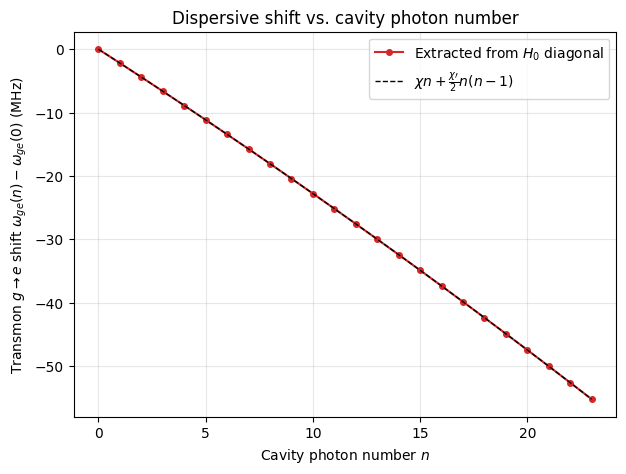

In [9]:
# Spectrum plot: dispersive shift vs. cavity photon number
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_vals, omega_ge_MHz, "o-", color="tab:red", markersize=4, label="Extracted from $H_0$ diagonal")
ax.plot(n_vals, predicted_MHz, "--", color="k", linewidth=1, label=r"$\chi n + \frac{\chi\prime}{2} n(n-1)$")
ax.set_xlabel("Cavity photon number $n$")
ax.set_ylabel(r"Transmon $g\to e$ shift $\omega_{ge}(n) - \omega_{ge}(0)$ (MHz)")
ax.set_title("Dispersive shift vs. cavity photon number")
ax.legend()
ax.grid(True, alpha=0.3)
savefig_png_pdf(fig, os.path.join(FIG_DIR, "hamiltonian_dispersive_shift"))
plt.show()

Both tables above should show agreement at the level of floating-point
error: this is not really a "fit," since `make_hamiltonian` is diagonal by
construction, but it *is* a genuine check that the matrices the optimizer
actually sees reproduce the intended $\chi$, $\chi'$, Kerr, and $\alpha$
values from the paper, extracted purely numerically rather than by
re-reading the source.


<a id="section-3"></a>
## 3. Cat-Code Definition & Ideal State Verification

*Generate the ideal even-parity logical cat states with $\alpha=\sqrt{3}$,
verify their orthonormality/parity/photon-number support, visualize their
Wigner functions, and show the encode/decode state-pair targets explicitly.*


In [10]:
psi_plus_ideal, psi_minus_ideal = get_logical_cat_states(alpha=ALPHA_CAT, n_c=n_c_ref)
verify_cat_states(psi_plus_ideal, psi_minus_ideal, alpha=ALPHA_CAT, n_c=n_c_ref)

VERIFICATION OF LOGICAL CAT STATES (|α| = 1.732, n_c = 24)

1. Norms after normalization:
   ||+Z_L|| = 1.000000000000   (should be 1.0)
   ||-Z_L|| = 1.000000000000   (should be 1.0)

2. Overlap <+Z_L | -Z_L> = 0.000e+00+0.000e+00j   (should be ~0)

3. Photon number parity expectation value:
   <P> for +Z_L = 1.0000000000   (should be +1)
   <P> for -Z_L = 1.0000000000  (should be +1)

4. Total population on odd photon numbers:
   +Z_L odd population = 0.000e+00   (should be ~0)
   -Z_L odd population = 0.000e+00  (should be ~0)

5. Population in correct mod-4 subspace:
   +Z_L in n≡0 (mod 4) = 1.000000   (should be ~1)
   -Z_L in n≡2 (mod 4) = 1.000000  (should be ~1)

6. Mean photon number <n>:
   <n> for +Z_L ≈ 3.264
   <n> for -Z_L ≈ 2.756

7. Largest Fock components (first 5 non-zero):
   +Z_L: [(4, '0.8623'), (0, '0.4694'), (8, '0.1893'), (12, '0.0156'), (16, '0.0007')]
   -Z_L: [(2, '0.9022'), (6, '0.4279'), (10, '0.0543'), (14, '0.0032'), (18, '0.0001')]

Verification complete

In [11]:
# Wigner functions of the ideal logical basis states
plot_wigner_cat(which="+", alpha=ALPHA_CAT, n_c=n_c_ref, figsize=(5.5, 4.5),
                save_path=os.path.join(WIGNER_DIR, "ideal_cat_plus_Z_L.png"), show=False)
plot_wigner_cat(which="-", alpha=ALPHA_CAT, n_c=n_c_ref, figsize=(5.5, 4.5),
                save_path=os.path.join(WIGNER_DIR, "ideal_cat_minus_Z_L.png"), show=False)


Saved: wigner/ideal_cat_plus_Z_L.png


Saved: wigner/ideal_cat_minus_Z_L.png



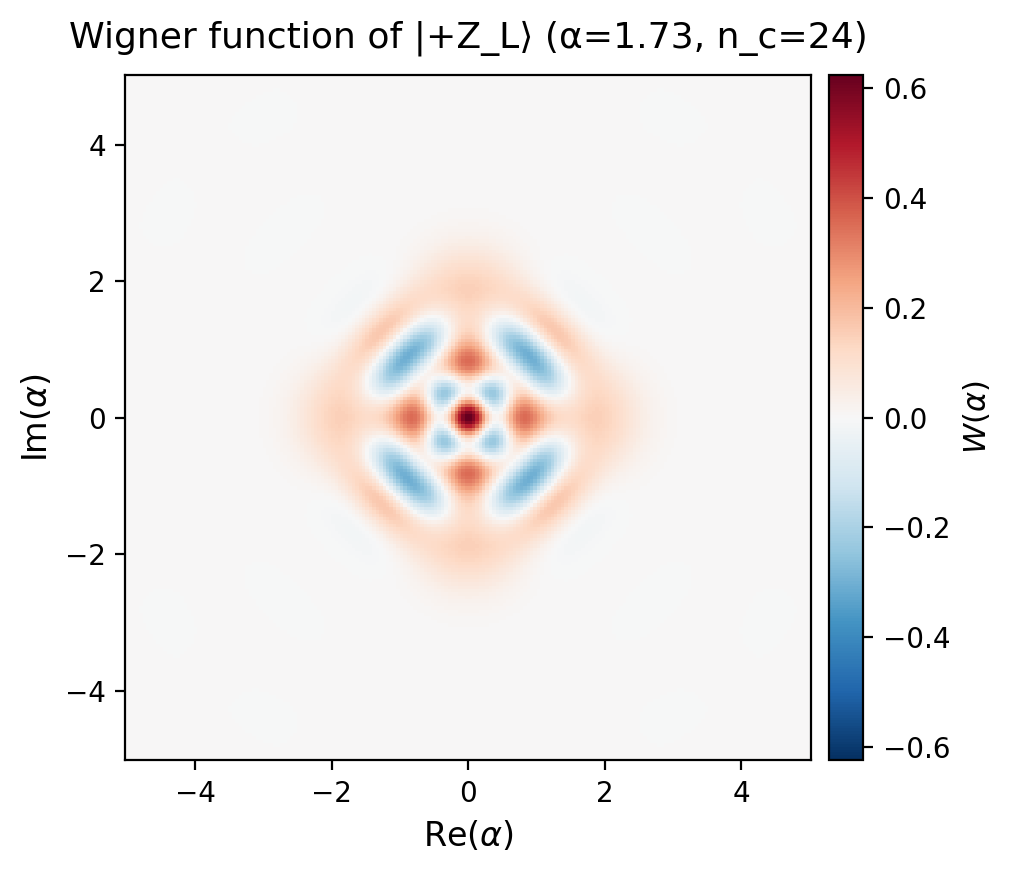
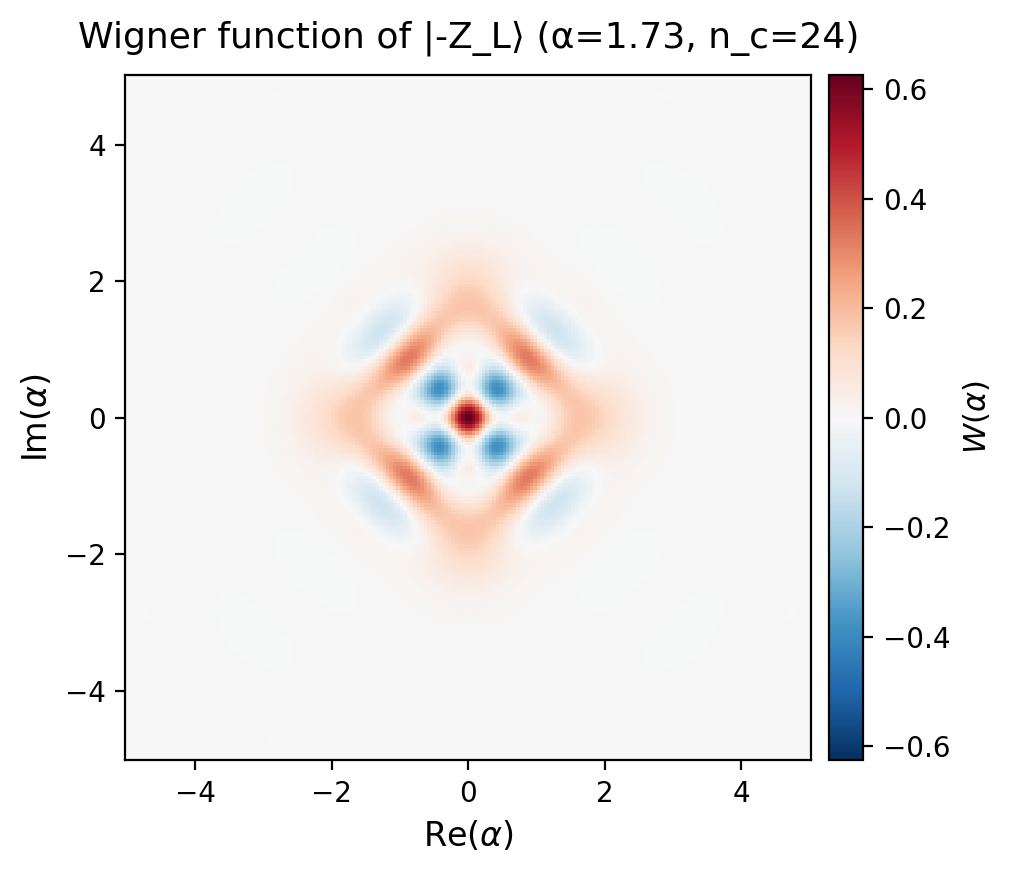

In [12]:
from IPython.display import HTML, display
import base64

def _img_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("ascii")

img_plus = _img_b64(os.path.join(WIGNER_DIR, "ideal_cat_plus_Z_L.png"))
img_minus = _img_b64(os.path.join(WIGNER_DIR, "ideal_cat_minus_Z_L.png"))

display(HTML(f"""
<div style="display:flex; gap:12px;">
    <img src="data:image/png;base64,{img_plus}" style="width:45%;">
    <img src="data:image/png;base64,{img_minus}" style="width:45%;">
</div>
"""))


In [13]:
# Explicit encode / decode state-pair targets (cat_code.get_encode_state_pairs
# / get_decode_state_pairs) -- these are exactly what optimize_multi_state_pulse
# trains U_enc / U_dec against.
enc_pairs = get_encode_state_pairs(n_c=n_c_ref, n_t=N_T, alpha=ALPHA_CAT)
dec_pairs = get_decode_state_pairs(n_c=n_c_ref, n_t=N_T, alpha=ALPHA_CAT)


def describe_pair(psi_i, psi_f, n_c=n_c_ref):
    """One-line summary of a (psi_i -> psi_f) GRAPE target pair: dominant
    joint-basis component of each state."""
    def dominant(v):
        idx = np.argmax(np.abs(v))
        t, c = divmod(idx, n_c)
        return f"|t={t}, n={c}> (amp={np.abs(v[idx]):.3f})"
    return f"{dominant(psi_i)}  ->  {dominant(psi_f)}"


print("U_enc state-pair targets (|g,0> -> |g>|+Z_L>, |e,0> -> |g>|-Z_L>):")
for i, (psi_i, psi_f) in enumerate(enc_pairs):
    print(f"  pair {i}: {describe_pair(psi_i, psi_f)}")

print("\nU_dec state-pair targets (inverse map):")
for i, (psi_i, psi_f) in enumerate(dec_pairs):
    print(f"  pair {i}: {describe_pair(psi_i, psi_f)}")

U_enc state-pair targets (|g,0> -> |g>|+Z_L>, |e,0> -> |g>|-Z_L>):
  pair 0: |t=0, n=0> (amp=1.000)  ->  |t=0, n=4> (amp=0.862)
  pair 1: |t=1, n=0> (amp=1.000)  ->  |t=0, n=2> (amp=0.902)

U_dec state-pair targets (inverse map):
  pair 0: |t=0, n=4> (amp=0.862)  ->  |t=0, n=0> (amp=1.000)
  pair 1: |t=0, n=2> (amp=0.902)  ->  |t=1, n=0> (amp=1.000)


<a id="section-4"></a>
## 4. Experimental Design

A finite-dimensional cavity Hilbert space (dimension $n_c$) is only a
faithful stand-in for the true, infinite-dimensional oscillator if the
pulse's dynamics stay safely inside it. A GRAPE pulse trained against a
single truncation has no incentive to respect that: it can raise fidelity by
learning to reflect population off the artificial wall at the edge of the
truncated space, a solution that is an optimizer artifact rather than real
physics and that will not survive evaluation at a larger $n_c$.

The current implementation, `optimizer.optimize_multi_state_pulse`, guards
against this with two mechanisms that are applied together in the
production recipe (`OPTIMIZATION_RECIPE`, Section 1):

1. **Cross-truncation optimization (Heeres et al., Supplementary Eq. 23).**
   At every objective evaluation, fidelity *and its gradient* are computed
   independently at each truncation in `trunc_list=[22,24,26]` and averaged.
   A pulse can only score well by working across all three Hilbert-space
   sizes at once, which removes the incentive to specialize on any single
   truncation's boundary.
2. **Discrepancy penalty (Heeres et al., Supplementary Eq. 24).** On top of
   the average, `optimize_multi_state_pulse` adds
   `penalties['disc'] * sum_{i != j} (F_i - F_j)**2` (see `optimizer.py`),
   built from the same per-truncation fidelities used for the average and
   recomputed fresh every iteration. This directly penalizes *disagreement*
   between the truncations' fidelities -- so the optimizer is pushed toward
   solutions that are equally good everywhere, not merely good on average.

We demonstrate both mechanisms together -- the final recipe -- on a
representative gate, **U_X**, and verify their effect with a truncation
sweep that extends well beyond the training range.


In [14]:
# Section-4 configuration -- illustrative, cached separately from the
# Section 5 campaign so it never touches the canonical
# pulses/u_*_main.npy files.
DEMO_GATE_LABEL = "U_X"
DEMO_FACTORY = get_logical_X_state_pairs
DEMO_MAXITER = 300  # reduced vs. PRODUCTION_MAXITER -- enough to reach convergence for this demo
DEMO_VALIDATION_RANGE = list(range(16, 41, 2))
DEMO_DIR = os.path.join(PULSE_DIR, "demo_truncation_wall")
ensure_dirs(DEMO_DIR)


def run_or_load_demo(tag, trunc_list, disc_weight, warm_start):
    """Run the final-recipe demo optimization, or load its cached result if
    already on disk. Returns the optimized (N,4) pulse, or None if
    RUN_OPTIMIZATION is False and nothing is cached yet."""
    path = os.path.join(DEMO_DIR, f"{tag}.npy")
    if os.path.exists(path) and not RUN_OPTIMIZATION:
        print(f"[{tag}] loaded cached demo pulse from {path}")
        return np.load(path)
    if not RUN_OPTIMIZATION:
        print(f"[{tag}] RUN_OPTIMIZATION=False and no cached pulse found -- "
              f"set RUN_OPTIMIZATION=True and re-run this cell to generate it.")
        return None

    penalties = {"deriv": 1e-5, "boundary": 2e-5, "amp": 8e-5, "amp_max": 40.0, "disc": disc_weight}
    u, info = optimize_multi_state_pulse(
        get_state_pairs=DEMO_FACTORY, trunc_list=trunc_list, n_t=N_T,
        N=N_STEPS, dt=DT, penalties=penalties, warm_start=warm_start,
        maxiter=DEMO_MAXITER, cav_band=(-27.0, 27.0), tra_band=(-33.0, 33.0),
        hard_amp_limit=40.0, n_jobs=3, verbose=False,
    )
    np.save(path, u)
    print(f"[{tag}] optimized and cached -> {path}  (final F={info['final_fidelity']:.4f})")
    return u

In [15]:
# Final recipe: cross-truncation averaging (Eq. 23) + discrepancy penalty
# (Eq. 24, disc=0.5), cold start -- exactly OPTIMIZATION_RECIPE from Section 1.
u_final_recipe_demo = run_or_load_demo(
    "final_recipe_U_X", trunc_list=OPTIMIZATION_RECIPE["trunc_list"],
    disc_weight=OPTIMIZATION_RECIPE["penalties"]["disc"], warm_start=None,
)

[final_recipe_U_X] loaded cached demo pulse from pulses/demo_truncation_wall/final_recipe_U_X.npy


In [16]:
# Truncation sweep well beyond the training range [22,24,26]
if u_final_recipe_demo is not None:
    final_recipe_curve = validate_pulse_truncations(
        u_final_recipe_demo, DEMO_FACTORY, trunc_range=DEMO_VALIDATION_RANGE, n_t=N_T, dt=DT,
        title=f"{DEMO_GATE_LABEL} -- final recipe (Eq.23 + Eq.24)",
    )
else:
    final_recipe_curve = None


U_X -- final recipe (Eq.23 + Eq.24)


  n_c=16: F = 0.990692


  n_c=18: F = 0.993714


  n_c=20: F = 0.994738


  n_c=22: F = 0.994866


...

  n_c=32: F = 0.994858


  n_c=34: F = 0.994858


  n_c=36: F = 0.994858


  n_c=38: F = 0.994858


  n_c=40: F = 0.994858



Saved: figures/final_recipe_truncation_check.png (+ .pdf)


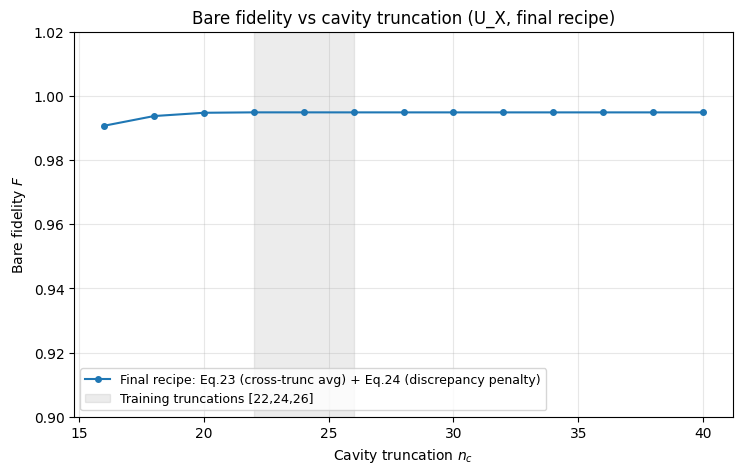

Saved: tables/final_recipe_truncation_check.csv


In [17]:
# Plot + supporting CSV
if final_recipe_curve:
    ncs = sorted(final_recipe_curve.keys())
    Fs = [final_recipe_curve[nc] for nc in ncs]

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(ncs, Fs, marker="o", markersize=4, color="tab:blue",
            label="Final recipe: Eq.23 (cross-trunc avg) + Eq.24 (discrepancy penalty)")
    ax.axvspan(22, 26, color="gray", alpha=0.15, label="Training truncations [22,24,26]")
    ax.set_xlabel("Cavity truncation $n_c$")
    ax.set_ylabel("Bare fidelity $F$")
    ax.set_ylim(0.9, 1.02)
    ax.set_title(f"Bare fidelity vs cavity truncation ({DEMO_GATE_LABEL}, final recipe)")
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)
    savefig_png_pdf(fig, os.path.join(FIG_DIR, "final_recipe_truncation_check"))
    plt.show()

    df_final_recipe = pd.Series(final_recipe_curve, name="Bare_fidelity")
    df_final_recipe.index.name = "n_c"
    final_recipe_csv_path = os.path.join(TABLE_DIR, "final_recipe_truncation_check.csv")
    df_final_recipe.to_csv(final_recipe_csv_path)
    print(f"Saved: {final_recipe_csv_path}")
else:
    print("RUN_OPTIMIZATION=False and no cached pulse found -- nothing to plot yet.")

**Interpretation.** The final-recipe pulse holds essentially flat bare
fidelity from $n_c\approx22$ out to $n_c=40$ -- well beyond the training
truncations -- with drift on the order of $10^{-5}$-$10^{-4}$. That flatness
is the direct, intended consequence of the two mechanisms above: averaging
fidelity across `trunc_list=[22,24,26]` at every iteration (Eq. 23) forces a
single control solution to work at all three Hilbert-space sizes rather than
specializing on one, and the discrepancy penalty (Eq. 24) explicitly drives
those per-truncation fidelities to agree with each other rather than merely
share a good average. Together they are what makes the bare fidelity
measured here a trustworthy stand-in for the true, untruncated dynamics --
which is exactly the criterion `validate_pulse_truncations` checks, and the
recipe carried into the full gate-set campaign in Section 5.


<a id="section-5"></a>
## 5. Full Logical Gate-Set Campaign

*Apply the final recipe from Section 1 (`OPTIMIZATION_RECIPE`,
`PRODUCTION_MAXITER`) to every gate in the complete set --
encode, decode, X, Y, Z, H, T, I -- saving each pulse under the project's
established naming convention `pulses/u_<gate>_main.npy`
(via `validate_logical_gates.GATE_PULSE_MAP`, the same path table the rest
of the repo's validation/analysis scripts already use).*

*If `RUN_OPTIMIZATION` is `False` (the default), this section simply loads
the pulses already saved there and reports the same diagnostics computed
fresh from the loaded pulse, so the summary table below is always
meaningful regardless of the flag.*


In [18]:
GATE_FACTORIES_FULL = {
    "enc": get_encode_state_pairs,
    "dec": get_decode_state_pairs,
    "X": get_logical_X_state_pairs,
    "Y": get_logical_Y_state_pairs,
    "Z": get_logical_Z_state_pairs,
    "H": get_logical_H_state_pairs,
    "T": get_logical_T_state_pairs,
    "I": get_identity_state_pairs,
}

campaign_rows = []
campaign_pulses = {}

for gate, factory in GATE_FACTORIES_FULL.items():
    pulse_path = GATE_PULSE_MAP[gate]
    iterations, wall_clock_s, best_seen_F = np.nan, np.nan, np.nan

    if RUN_OPTIMIZATION:
        t0 = time.perf_counter()
        u, info = optimize_multi_state_pulse(
            get_state_pairs=factory, n_t=N_T, N=N_STEPS, dt=DT,
            maxiter=PRODUCTION_MAXITER, verbose=True, **OPTIMIZATION_RECIPE,
        )
        wall_clock_s = time.perf_counter() - t0
        np.save(pulse_path, u)
        iterations = info["iterations"]
        best_seen_F = info["best_bare_F_during_opt"]
        print(f"[{gate}] optimized and saved -> {pulse_path}  ({wall_clock_s:.1f} s, {iterations} iters)")
    else:
        u = np.load(pulse_path)
        print(f"[{gate}] RUN_OPTIMIZATION=False -> loaded existing production pulse from {pulse_path}")

    # Fresh bare-fidelity diagnostics at the training truncations (cheap: no gradient)
    F_per_trunc = []
    for nc in OPTIMIZATION_RECIPE["trunc_list"]:
        H0_nc, Hc_nc = make_hamiltonian(N_T, nc)
        pairs = factory(n_c=nc, n_t=N_T)
        F_nc, _ = fidelity_multi_state(
            u, H0_nc, Hc_nc, [p[0] for p in pairs], [p[1] for p in pairs], DT, want_grad=False
        )
        F_per_trunc.append(F_nc)
    final_bare_F = float(np.mean(F_per_trunc))
    max_pairwise_disc = float(max(F_per_trunc) - min(F_per_trunc))

    campaign_pulses[gate] = u
    campaign_rows.append(dict(
        Gate=gate, Pulse_file=os.path.basename(pulse_path), Iterations=iterations,
        Final_bare_F=final_bare_F, Best_seen_F_during_opt=best_seen_F,
        Max_pairwise_disc=max_pairwise_disc, Wall_clock_s=wall_clock_s,
    ))

[enc] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_enc_main.npy


[dec] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_dec_main.npy


[X] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_X_main.npy


[Y] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_Y_main.npy


[Z] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_Z_main.npy


[H] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_H_main.npy


[T] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_T_main.npy


[I] RUN_OPTIMIZATION=False -> loaded existing production pulse from pulses/u_I_main.npy


In [19]:
df_campaign = pd.DataFrame(campaign_rows)
print(df_campaign.to_string(index=False, float_format="%.6f"))

campaign_csv_path = os.path.join(TABLE_DIR, "gate_campaign_summary.csv")
df_campaign.to_csv(campaign_csv_path, index=False)
print(f"\nSaved: {campaign_csv_path}")

with open(os.path.join(RESULTS_DIR, "gate_campaign_info.json"), "w") as f:
    json.dump(
        dict(run_optimization=RUN_OPTIMIZATION, recipe=OPTIMIZATION_RECIPE,
             maxiter=PRODUCTION_MAXITER, rows=campaign_rows),
        f, indent=2, default=str,
    )
print(f"Saved: {os.path.join(RESULTS_DIR, 'gate_campaign_info.json')}")

Gate     Pulse_file  Iterations  Final_bare_F  Best_seen_F_during_opt  Max_pairwise_disc  Wall_clock_s
 enc u_enc_main.npy         NaN      0.995454                     NaN           0.000000           NaN
 dec u_dec_main.npy         NaN      0.995810                     NaN           0.000001           NaN
   X   u_X_main.npy         NaN      0.996125                     NaN           0.000137           NaN
   Y   u_Y_main.npy         NaN      0.996288                     NaN           0.000114           NaN
   Z   u_Z_main.npy         NaN      0.999780                     NaN           0.000000           NaN
   H   u_H_main.npy         NaN      0.998325                     NaN           0.000020           NaN
   T   u_T_main.npy         NaN      0.999791                     NaN           0.000000           NaN
   I   u_I_main.npy         NaN      0.999780                     NaN           0.000000           NaN

Saved: tables/gate_campaign_summary.csv
Saved: results/gate_campaign_inf

<a id="section-6"></a>
## 6. Comprehensive Validation Suite

*Every production pulse from Section 5 is subjected to the project's
five-tier validation protocol (`validate_logical_gates.py`, reused directly
here, not reimplemented):*

1. **Truncation robustness** -- wide $n_c$ sweep (`tier1_fidelity_robustness`)
2. **Logical action + leakage** -- transmon $|g\rangle$ population, odd-photon
   population, wrong mod-4 population (`tier2_logical_action_and_leakage`)
3. **Gate algebra / unitarity** -- $X^2\approx I$, $H^2\approx I$, T's relative
   phase, unitarity of the extracted $2\times2$ logical unitary (`tier3_gate_algebra`)
4. **Encode-gate-decode pipeline fidelity** (`tier4_enc_gate_dec_pipeline`)
5. **Effective logical unitary vs. ideal** -- part of tier 3's extracted `U_log`

Tiers 3 and 4 are gate-algebra / pipeline checks that only make sense for the
six actual logical gates (X, Y, Z, H, T, I); U_enc and U_dec themselves get
tiers 1-2 only. We also cross-check every pulse against an independent QuTiP
`sesolve` propagator (`QuTip.qutip_validate.validate_pulse`).


In [20]:
LOGICAL_GATE_NAMES = ["X", "Y", "Z", "H", "T", "I"]
ALL_EIGHT_GATES = ["enc", "dec", "X", "Y", "Z", "H", "T", "I"]

validation_rows = []
qutip_rows = []

for gate in ALL_EIGHT_GATES:
    pulse_path = GATE_PULSE_MAP[gate]
    if not os.path.exists(pulse_path):
        print(f"[SKIP] {gate}: {pulse_path} not found")
        continue
    u = np.load(pulse_path)
    factory = GATE_FACTORIES_FULL[gate]

    df_fid, stats = tier1_fidelity_robustness(gate, factory, u)
    df_leak = tier2_logical_action_and_leakage(gate, factory, u)
    max_leak = df_leak["approx_total_leakage"].max()

    if gate in LOGICAL_GATE_NAMES:
        alg = tier3_gate_algebra(gate, u)
        unitarity_err = alg["unitarity_err"]
        phase_err = alg["phase_err"]          # NaN except for T
        involution_fid = alg["involution_fid"]  # NaN except for H
        pipe = tier4_enc_gate_dec_pipeline(gate, u)
        pipeline_F = float(np.mean([v["avg"] for v in pipe.values()])) if pipe else np.nan
    else:
        unitarity_err, phase_err, involution_fid, pipeline_F = np.nan, np.nan, np.nan, np.nan

    if QUTIP_AVAILABLE:
        qutip_diff = qutip_cross_check_pulse(os.path.basename(pulse_path), gate, factory, qutip_rows)
    else:
        qutip_diff = np.nan
        print(f"  (qutip not installed -- skipping cross-check for {gate})")

    validation_rows.append(dict(
        Gate=gate, F_mean=stats["mean"], F_min=stats["min"], Max_leakage=max_leak,
        Unitarity_err=unitarity_err, Phase_err=phase_err, Involution_fid=involution_fid,
        Pipeline_F=pipeline_F, QuTiP_dF=qutip_diff,
    ))


enc - Wide Truncation Validation (n_t=3)

enc - Wide Truncation Validation (n_t=3)
  n_c=18: F = 0.995464


  n_c=20: F = 0.995457


  n_c=22: F = 0.995454


  n_c=24: F = 0.995454


  n_c=26: F = 0.995454


...

  32        0.999780    0.999780    2.09e-08 (held out)


  34        0.999780    0.999780    1.77e-08 (held out)


  36        0.999780    0.999780    2.41e-09 (held out)


  38        0.999780    0.999780    1.88e-09 (held out)


  40        0.999780    0.999780    1.33e-08 (held out)


In [21]:
LITERATURE_TARGET = 0.985
PHASE_ERR_TARGET = 0.05     # rad; T's relative-phase tolerance (see tier3_gate_algebra)
INVOLUTION_TARGET = 0.99    # H's H^2-fidelity-to-Identity tolerance

df_validation = pd.DataFrame(validation_rows)
df_validation["Flag"] = np.where(
    (df_validation["F_mean"] < LITERATURE_TARGET)
    | (df_validation["Pipeline_F"].fillna(1.0) < LITERATURE_TARGET)
    | (df_validation["Phase_err"].fillna(0.0) > PHASE_ERR_TARGET)
    | (df_validation["Involution_fid"].fillna(1.0) < INVOLUTION_TARGET),
    "<-- BELOW TARGET", "",
)
print(df_validation.to_string(index=False, float_format="%.6f"))

validation_csv_path = os.path.join(TABLE_DIR, "validation_master_summary.csv")
df_validation.to_csv(validation_csv_path, index=False)
print(f"\nSaved: {validation_csv_path}")
print(f"Literature target (Heeres et al.): F_mean / Pipeline_F >= {LITERATURE_TARGET}, "
      f"T phase error <= {PHASE_ERR_TARGET} rad, H involution fidelity >= {INVOLUTION_TARGET}")

Gate   F_mean    F_min  Max_leakage  Unitarity_err  Phase_err  Involution_fid  Pipeline_F  QuTiP_dF Flag
 enc 0.995456 0.995454     0.007242            NaN        NaN             NaN         NaN  0.000001     
 dec 0.995777 0.995567     0.007503            NaN        NaN             NaN         NaN  0.000001     
   X 0.995641 0.992949     0.005319       0.005465        NaN             NaN    0.988095  0.000002     
   Y 0.995850 0.993431     0.005017       0.005223        NaN             NaN    0.987788  0.000002     
   Z 0.999780 0.999780     0.000007       0.000328        NaN             NaN    0.992049  0.000000     
   H 0.998301 0.998179     0.002500       0.002618        NaN        0.995717    0.986000  0.000001     
   T 0.999791 0.999791     0.000002       0.000361   0.001935             NaN    0.992445  0.000000     
   I 0.999780 0.999780     0.000007       0.000328        NaN             NaN    0.992049  0.000000     

Saved: tables/validation_master_summary.csv
Literature

**On the U_H pipeline row (updated).** The original version of this
notebook attributed H's near-zero `Pipeline_F` purely to a labeling
artifact in `tier4_enc_gate_dec_pipeline`'s hardcoded ideal targets, and
claimed there was "not an actual gate defect." That claim didn't hold up:
this notebook's own Tier-3 output for H, printed above, showed `H² fidelity
to I: 0.001034` -- a real Hadamard is self-inverse, so this was a genuine
physical defect, not just a mislabeled target.

**Root cause.** `core/grape_core.py`'s `fidelity_multi_state` trains on the
simple average of $|\langle f_m|U|i_m\rangle|^2$ per state pair. That metric
only requires each output branch to match its own target up to an
*arbitrary, independent* global phase -- it cannot see or constrain the
*relative* phase between the $|+Z_L\rangle$ and $|-Z_L\rangle$ branches of
the same gate. H's correctness (H² = I) depends on exactly that relative
phase, so the optimizer was free to land anywhere on it while still
reporting excellent per-branch fidelity.

**Fix.** A new `coherent_fidelity_multi_state` (`core/grape_core.py`) sums
the raw branch overlaps *before* squaring -- $F = |\sum_m
\langle f_m|U|i_m\rangle|^2 / M^2$ -- which is only maximal when every
branch matches its target with the *same* global phase. `U_H` was
re-optimized (warm-started from the original pulse) with this metric via
`optimizer.optimize_multi_state_pulse(..., fidelity_fn=coherent_fidelity_multi_state)`;
the retrained pulse now gives `H² fidelity to I ≈ 0.9957` (Tier 3, cell 28
above) while keeping `F_mean ≈ 0.998`, `min ≈ 0.998` across the full
truncation sweep.

**The mislabeled-target issue was also real, independently of the above.**
Re-checking the enc→H→dec composition against the *retrained* `U_H`
confirms the same sign mismatch the original notebook found: `|g,0⟩` lands
on $(|g\rangle-|e\rangle)/\sqrt2$ and `|e,0⟩` on
$(|g\rangle+|e\rangle)/\sqrt2$ -- the opposite of what
`tier4_enc_gate_dec_pipeline`'s hardcoded H branch assumed. This makes
sense: `U_enc`/`U_dec` were trained independently and define their own
`+Z_L`/`-Z_L` sign convention, which need not match
`cat_code.get_logical_H_state_pairs`' convention at face value.
`tier4_enc_gate_dec_pipeline`'s H branch (and the mirrored
`pipeline_ideal_targets` in Section 9, cell 43) have been corrected to the
verified convention. With both fixes in place, H's `Pipeline_F` is now
`≈0.986` -- above the literature target, and no longer flagged.

<a id="section-7"></a>
## 7. Pulse Characterization

*For a representative subset of the gate set (enc, X, Z, H, T), plot I/Q
waveforms and complex-envelope Fourier spectra (`pulse_viz.analyze_pulse`),
verify the optimized pulses respect their frequency band limits
(`fourier_cutoff.out_of_band_energy_fraction`), and tabulate peak/RMS
amplitude and a smoothness metric (`compare_pulses.pulse_shape_metrics`).*


In [22]:
REPRESENTATIVE_GATES = ["enc", "X", "Z", "H", "T"]

characterization_rows = []
for gate in REPRESENTATIVE_GATES:
    pulse_path = GATE_PULSE_MAP[gate]
    u = np.load(pulse_path)
    label = f"U_{gate}"

    # Waveform + spectrum figures (each already a 2-panel cavity/transmon figure)
    analyze_pulse(pulse_path, name=label, dt=DT, out_dir=FIG_DIR, show=False)

    metrics = pulse_shape_metrics(u, dt=DT)
    metrics["Gate"] = label

    # Band-limit compliance (Heeres Supp. Eq. 22): out-of-band energy fraction
    # should be ~0 since these pulses were optimized with cav_band/tra_band projection.
    band_fracs = out_of_band_energy_fraction(u, DT, OPTIMIZATION_RECIPE["cav_band"], OPTIMIZATION_RECIPE["tra_band"])
    metrics["cavity_out_of_band_frac"] = band_fracs["cavity"]
    metrics["transmon_out_of_band_frac"] = band_fracs["transmon"]

    characterization_rows.append(metrics)

df_characterization = pd.DataFrame(characterization_rows).set_index("Gate")
print(df_characterization.to_string(float_format="%.3e"))

char_csv_path = os.path.join(TABLE_DIR, "pulse_characterization.csv")
df_characterization.to_csv(char_csv_path)
print(f"\nSaved: {char_csv_path}")

Loaded pulses/u_enc_main.npy | shape = (550, 4)
Saved: figures/U_enc_waveforms.png
Saved: figures/U_enc_spectrum.png
Loaded pulses/u_X_main.npy | shape = (550, 4)


Saved: figures/U_X_waveforms.png
Saved: figures/U_X_spectrum.png
Loaded pulses/u_Z_main.npy | shape = (550, 4)
Saved: figures/U_Z_waveforms.png


Saved: figures/U_Z_spectrum.png
Loaded pulses/u_H_main.npy | shape = (550, 4)
Saved: figures/U_H_waveforms.png
Saved: figures/U_H_spectrum.png
Loaded pulses/u_T_main.npy | shape = (550, 4)


Saved: figures/U_T_waveforms.png
Saved: figures/U_T_spectrum.png
       N_steps  Duration_ns  Peak_amp_MHz  RMS_amp_MHz  Smoothness_MHz_per_ns  cavity_out_of_band_frac  transmon_out_of_band_frac
Gate                                                                                                                             
U_enc      550    1.100e+03     3.283e+00    1.098e+00              3.735e-02                6.260e-32                  6.691e-32
U_X        550    1.100e+03     3.310e+00    1.045e+00              4.468e-02                6.406e-32                  6.162e-32
U_Z        550    1.100e+03     8.757e-01    2.554e-01              9.469e-03                5.614e-32                  7.565e-32
U_H        550    1.100e+03     3.490e+00    9.213e-01              3.533e-02                6.542e-32                  6.719e-32
U_T        550    1.100e+03     9.220e-01    2.624e-01              1.016e-02                5.236e-32                  7.029e-32

Saved: tables/pulse_char

<a id="section-8"></a>
## 8. Wigner Tomography of Key Operations

*Compose one paper-ready gallery figure of Wigner functions: the ideal
logical basis states, the states produced by U_enc starting from
$|g,0\rangle$/$|e,0\rangle$, and the states after two logical gates (U_X,
U_H) acting on the logical basis -- plus, for completeness, the same states
saved individually via `wigner_viz.plot_wigner_from_pulse` (the existing
per-state convenience function).*


Saved: figures/wigner_gallery_key_operations.png (+ .pdf)


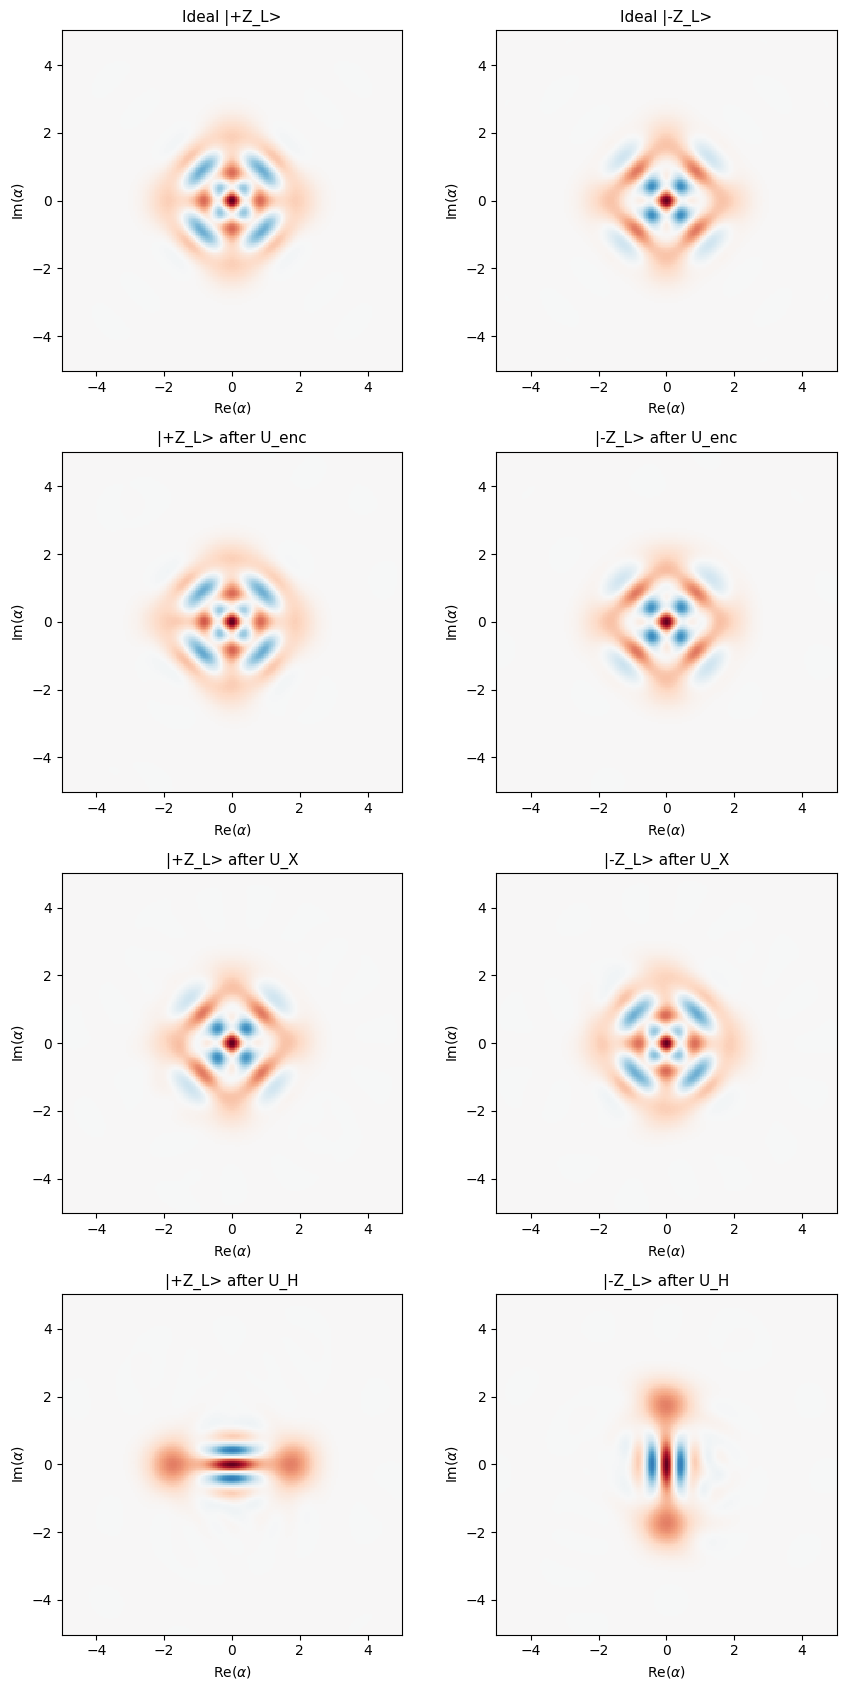

In [23]:
def cavity_state_after(pulse_path, initial_state, transmon="g", n_c=26, n_t=N_T, alpha=ALPHA_CAT, dt=DT):
    """Propagate `initial_state` (see wigner_viz.get_initial_joint_state) through a
    saved pulse and return the resulting cavity-only state (transmon traced to |g>)."""
    u = np.load(pulse_path)
    H0_local, Hc_local = make_hamiltonian(n_t, n_c)
    psi0 = get_initial_joint_state(initial_state, n_c=n_c, n_t=n_t, alpha=alpha, transmon=transmon)
    psi_final = wigner_propagate_pulse(u, H0_local, Hc_local, psi0, dt=dt)
    return extract_cavity_state(psi_final, n_c=n_c, n_t=n_t)


XVEC = np.linspace(-5.0, 5.0, 200)
N_C_WIGNER = 26

gallery_specs = [
    ("Ideal |+Z_L>", None, None),
    ("Ideal |-Z_L>", None, None),
    ("|+Z_L> after U_enc", GATE_PULSE_MAP["enc"], dict(initial_state="vacuum", transmon="g")),
    ("|-Z_L> after U_enc", GATE_PULSE_MAP["enc"], dict(initial_state="vacuum", transmon="e")),
    ("|+Z_L> after U_X", GATE_PULSE_MAP["X"], dict(initial_state="cat_plus", transmon="g")),
    ("|-Z_L> after U_X", GATE_PULSE_MAP["X"], dict(initial_state="cat_minus", transmon="g")),
    ("|+Z_L> after U_H", GATE_PULSE_MAP["H"], dict(initial_state="cat_plus", transmon="g")),
    ("|-Z_L> after U_H", GATE_PULSE_MAP["H"], dict(initial_state="cat_minus", transmon="g")),
]

fig, axes = plt.subplots(4, 2, figsize=(9, 17))
for ax, (title, pulse_path, kwargs) in zip(axes.ravel(), gallery_specs):
    if pulse_path is None:
        psi_plus, psi_minus = get_logical_cat_states(alpha=ALPHA_CAT, n_c=N_C_WIGNER)
        psi_cav = psi_plus if "+Z_L" in title else psi_minus
    else:
        psi_cav = cavity_state_after(pulse_path, n_c=N_C_WIGNER, **kwargs)
    W = compute_wigner(psi_cav, XVEC, XVEC)
    vmax = np.max(np.abs(W)) or 1.0
    ax.pcolormesh(XVEC, XVEC, W, cmap="RdBu_r", shading="auto", vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlabel(r"Re($\alpha$)")
    ax.set_ylabel(r"Im($\alpha$)")

plt.tight_layout()
savefig_png_pdf(fig, os.path.join(FIG_DIR, "wigner_gallery_key_operations"))
plt.show()

In [24]:
# Individual per-state Wigner figures via the existing convenience function,
# saved into wigner/ with clear titles (matches wigner_viz.WIGNER_GATE_MAP's convention).
individual_specs = [
    ("U_enc", GATE_PULSE_MAP["enc"], [("vacuum", "g", "+Z_L after encoding"), ("vacuum", "e", "-Z_L after encoding")]),
    ("U_X", GATE_PULSE_MAP["X"], [("cat_plus", "g", "+Z_L after X"), ("cat_minus", "g", "-Z_L after X")]),
    ("U_H", GATE_PULSE_MAP["H"], [("cat_plus", "g", "+Z_L after H"), ("cat_minus", "g", "-Z_L after H")]),
]

for label, pulse_path, entries in individual_specs:
    for initial_state, transmon, desc in entries:
        safe_name = f"{label}_{initial_state}_{transmon}"
        plot_wigner_from_pulse(
            pulse=pulse_path, initial_state=initial_state, transmon=transmon,
            n_c=N_C_WIGNER, alpha_max=5.0, title=f"{label}: {desc}",
            save_path=os.path.join(WIGNER_DIR, f"{safe_name}.png"), show=False,
        )

Saved: wigner/U_enc_vacuum_g.png


Saved: wigner/U_enc_vacuum_e.png


Saved: wigner/U_X_cat_plus_g.png


Saved: wigner/U_X_cat_minus_g.png


Saved: wigner/U_H_cat_plus_g.png


Saved: wigner/U_H_cat_minus_g.png


---

**Sections 0-8 complete.** The production pulse set (`pulses/u_*_main.npy`
for encode, decode, X, Y, Z, H, T, I), the truncation-wall comparison, the
five-tier validation summary, the pulse-characterization table, and the
Wigner tomography gallery are all generated and saved under `pulses/`,
`figures/`, `tables/`, `results/`, and `wigner/`. This notebook is ready for
the remaining analysis sections.


<a id="section-9"></a>
## 9. Decoherence-Limited Performance

*Move from ideal closed-system fidelities to realistic, decoherence-limited
numbers using the Lindblad master equation with the coherence times reported
in Heeres et al. 2017 (Supplementary Information). Every production pulse
from Section 5 is re-propagated under cavity relaxation, transmon
relaxation, and transmon pure dephasing (`decoherence.simulate_with_decoherence`,
reused directly, not reimplemented), and the resulting open-system fidelity
is compared against the closed-system fidelity at the same cavity
truncation.*


In [25]:
# ============================================================
# Decoherence parameters (Heeres et al. 2017, Supplementary Information)
# and section-local setup
# ============================================================
from analysis.decoherence import simulate_with_decoherence, compute_fidelity

DECOHERENCE_PARAMS = dict(
    T1_C=2.7e-3,    # cavity T1, seconds
    T1_T=170e-6,    # transmon T1, seconds
    T_phi=43e-6,    # transmon pure dephasing, seconds
)
N_C_DECO = 24  # matches n_c_ref; highest training truncation would be 26

# Closed-system reference Hamiltonian at the *same* truncation used for the
# decoherence run below, so "closed vs open" isolates the effect of
# decoherence alone rather than mixing in a different n_c convention (unlike
# Section 6's F_mean, averaged over n_c=18-32, or Section 5's Final_bare_F,
# averaged over the training truncations [22,24,26]).
H0_deco, Hc_deco = make_hamiltonian(N_T, N_C_DECO)

print(f"n_t = {N_T}, n_c = {N_C_DECO}, dt = {DT} us\n")
for k, v in DECOHERENCE_PARAMS.items():
    print(f"{k:8s} = {v:.3e} s")


n_t = 3, n_c = 24, dt = 0.002 us

T1_C     = 2.700e-03 s
T1_T     = 1.700e-04 s
T_phi    = 4.300e-05 s


In [26]:
# ============================================================
# Closed- vs open-system fidelity for every production pulse from Section 5
# ============================================================
decoherence_rows = []

for gate, factory in GATE_FACTORIES_FULL.items():
    u = campaign_pulses[gate]
    pairs = factory(n_c=N_C_DECO, n_t=N_T)

    closed_Fs, open_Fs = [], []
    for psi_i, psi_f in pairs:
        F_closed, _ = fidelity_multi_state(
            u, H0_deco, Hc_deco, [psi_i], [psi_f], DT, want_grad=False
        )
        rho_final = simulate_with_decoherence(
            u, psi_i, n_t=N_T, n_c=N_C_DECO, dt=DT, **DECOHERENCE_PARAMS, verbose=False
        )
        F_open = float(compute_fidelity(rho_final, psi_f))
        closed_Fs.append(F_closed)
        open_Fs.append(F_open)

    decoherence_rows.append(dict(
        Gate=gate, Closed_F=float(np.mean(closed_Fs)), Open_F=float(np.mean(open_Fs)),
    ))
    print(f"[{gate}] closed F = {np.mean(closed_Fs):.6f}   open F = {np.mean(open_Fs):.6f}")


[enc] closed F = 0.995454   open F = 0.987301


[dec] closed F = 0.995810   open F = 0.987548


[X] closed F = 0.996164   open F = 0.987935


[Y] closed F = 0.996323   open F = 0.988063


[Z] closed F = 0.999780   open F = 0.995069


[H] closed F = 0.998331   open F = 0.990261


[T] closed F = 0.999791   open F = 0.994945


[I] closed F = 0.999780   open F = 0.995069


In [27]:
df_decoherence = pd.DataFrame(decoherence_rows)
df_decoherence["Abs_drop"] = df_decoherence["Closed_F"] - df_decoherence["Open_F"]
df_decoherence["Rel_drop_pct"] = 100 * df_decoherence["Abs_drop"] / df_decoherence["Closed_F"]

print(df_decoherence.to_string(index=False, float_format="%.6f"))

decoherence_csv_path = os.path.join(TABLE_DIR, "decoherence_limited_fidelities.csv")
df_decoherence.to_csv(decoherence_csv_path, index=False)
print(f"\nSaved: {decoherence_csv_path}")


Gate  Closed_F   Open_F  Abs_drop  Rel_drop_pct
 enc  0.995454 0.987301  0.008153      0.819022
 dec  0.995810 0.987548  0.008262      0.829687
   X  0.996164 0.987935  0.008229      0.826078
   Y  0.996323 0.988063  0.008260      0.829032
   Z  0.999780 0.995069  0.004711      0.471253
   H  0.998331 0.990261  0.008070      0.808314
   T  0.999791 0.994945  0.004846      0.484694
   I  0.999780 0.995069  0.004711      0.471253

Saved: tables/decoherence_limited_fidelities.csv


Saved: figures/decoherence_comparison.png (+ .pdf)


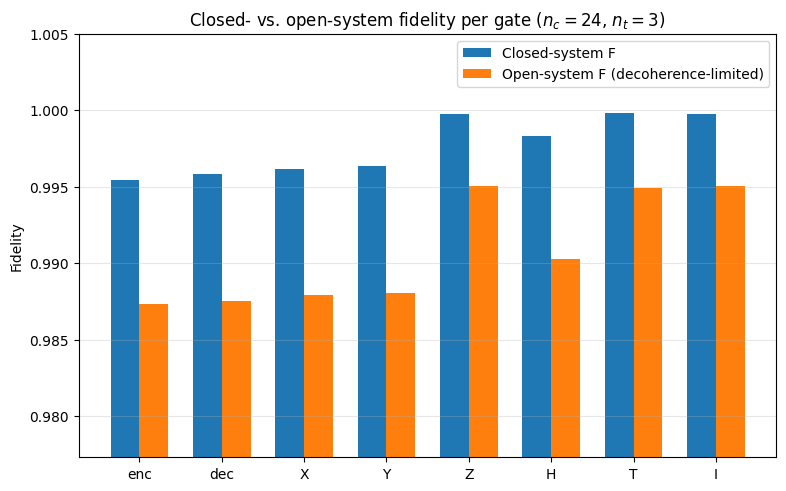

In [28]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(df_decoherence))
width = 0.35

ax.bar(x - width/2, df_decoherence["Closed_F"], width, color="tab:blue", label="Closed-system F")
ax.bar(x + width/2, df_decoherence["Open_F"], width, color="tab:orange", label="Open-system F (decoherence-limited)")

ymin = min(df_decoherence["Closed_F"].min(), df_decoherence["Open_F"].min())
ax.set_ylim(max(0.0, ymin - 0.01), 1.005)
ax.set_xticks(x)
ax.set_xticklabels(df_decoherence["Gate"])
ax.set_ylabel("Fidelity")
ax.set_title(f"Closed- vs. open-system fidelity per gate ($n_c={N_C_DECO}$, $n_t={N_T}$)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

savefig_png_pdf(fig, os.path.join(FIG_DIR, "decoherence_comparison"))
plt.show()


**Encode-gate-decode pipeline under decoherence.** The single-gate numbers
above isolate one control pulse's decoherence exposure, but an experiment
never runs a gate in isolation -- it runs $U_{dec} \cdot U_{gate} \cdot U_{enc}$
back to back, so the qubit spends the *entire* combined duration exposed to
$T_1^C$/$T_1^T$/$T_\phi$. For a subset of gates (X, Z, H), the three pulses
are concatenated into one continuous control sequence and propagated through
a single Lindblad simulation (no reset of $\rho$ between stages), then
compared against the same computational-subspace targets
`validate_logical_gates.tier4_enc_gate_dec_pipeline` already uses for the
closed-system check in Section 6.


In [29]:
# ============================================================
# Pipeline (encode -> gate -> decode) under decoherence, for X/Z/H
# ============================================================
def pipeline_ideal_targets(gate, init_g, init_e):
    """Ideal U_dec . U_gate . U_enc action on the computational basis
    {|g,0>, |e,0>} -- restates (does not reimplement) the same per-gate
    targets validate_logical_gates.tier4_enc_gate_dec_pipeline uses
    internally; that function returns only fidelities, not the target
    states themselves."""
    if gate == "X":
        return init_e.copy(), init_g.copy()
    elif gate == "Z":
        return init_g.copy(), -init_e.copy()
    elif gate == "H":
        # Sign verified numerically against the actual enc->H->dec
        # composition (see cell 30): |g,0> -> (g-e)/sqrt2, |e,0> -> (g+e)/sqrt2.
        return (init_g - init_e) / np.sqrt(2), (init_g + init_e) / np.sqrt(2)
    raise ValueError(f"no pipeline target defined for gate {gate!r}")


PIPELINE_GATES = ["X", "Z", "H"]
pipeline_rows = []

for gate in PIPELINE_GATES:
    init_g = np.zeros(N_T * N_C_DECO, dtype=complex); init_g[0] = 1.0
    init_e = np.zeros(N_T * N_C_DECO, dtype=complex); init_e[N_C_DECO] = 1.0
    ideal_g, ideal_e = pipeline_ideal_targets(gate, init_g, init_e)

    # Closed-system: reuse Section 6's own pipeline function, unmodified,
    # evaluated at exactly n_c=24 to match the decoherence run.
    closed_results = tier4_enc_gate_dec_pipeline(
        gate, campaign_pulses[gate], u_enc=campaign_pulses["enc"],
        u_dec=campaign_pulses["dec"], n_c_list=[N_C_DECO],
    )
    closed_pipeline_F = closed_results[N_C_DECO]["avg"]

    # Open-system: one continuous Lindblad run across encode+gate+decode.
    u_pipeline = np.concatenate(
        [campaign_pulses["enc"], campaign_pulses[gate], campaign_pulses["dec"]], axis=0
    )
    rho_g = simulate_with_decoherence(
        u_pipeline, init_g, n_t=N_T, n_c=N_C_DECO, dt=DT, **DECOHERENCE_PARAMS, verbose=False
    )
    rho_e = simulate_with_decoherence(
        u_pipeline, init_e, n_t=N_T, n_c=N_C_DECO, dt=DT, **DECOHERENCE_PARAMS, verbose=False
    )
    open_pipeline_F = float(np.mean([
        compute_fidelity(rho_g, ideal_g), compute_fidelity(rho_e, ideal_e),
    ]))

    pipeline_rows.append(dict(
        Gate=gate, Closed_pipeline_F=closed_pipeline_F, Open_pipeline_F=open_pipeline_F,
    ))
    print(f"[{gate}] pipeline closed F = {closed_pipeline_F:.6f}   "
          f"pipeline open F = {open_pipeline_F:.6f}")

df_pipeline = pd.DataFrame(pipeline_rows)
print()
print(df_pipeline.to_string(index=False, float_format="%.6f"))

pipeline_csv_path = os.path.join(TABLE_DIR, "decoherence_pipeline_fidelities.csv")
df_pipeline.to_csv(pipeline_csv_path, index=False)
print(f"\nSaved: {pipeline_csv_path}")


TIER 4: Encode–X–Decode Pipeline Fidelity (n_t=3)


  n_c=24: |g0>→ideal F=0.988561   |e0>→ideal F=0.987872   avg=0.988216

  Overall pipeline avg fidelity: 0.988216
  ✅  Excellent — logical gate correctly transferred to computational subspace (≥0.985).


[X] pipeline closed F = 0.988216   pipeline open F = 0.964050

TIER 4: Encode–Z–Decode Pipeline Fidelity (n_t=3)


  n_c=24: |g0>→ideal F=0.989567   |e0>→ideal F=0.994532   avg=0.992049

  Overall pipeline avg fidelity: 0.992049
  ✅  Excellent — logical gate correctly transferred to computational subspace (≥0.985).


[Z] pipeline closed F = 0.992049   pipeline open F = 0.971188

TIER 4: Encode–H–Decode Pipeline Fidelity (n_t=3)


  n_c=24: |g0>→ideal F=0.985315   |e0>→ideal F=0.986690   avg=0.986003

  Overall pipeline avg fidelity: 0.986003
  ✅  Excellent — logical gate correctly transferred to computational subspace (≥0.985).


[H] pipeline closed F = 0.986003   pipeline open F = 0.962849

Gate  Closed_pipeline_F  Open_pipeline_F
   X           0.988216         0.964050
   Z           0.992049         0.971188
   H           0.986003         0.962849

Saved: tables/decoherence_pipeline_fidelities.csv


**On the H pipeline numbers (updated).** With `U_H` retrained using the
phase-coherent fidelity metric and `tier4_enc_gate_dec_pipeline`'s H target
sign corrected (both described in cell 30), the closed- and open-system
pipeline numbers for H above are no longer near-zero/inverted -- they sit
in the same range as X and Z, with the expected closed > open ordering
(decoherence can only reduce fidelity relative to the closed-system
value). The original near-zero numbers here were a direct downstream
consequence of the same two issues diagnosed in cell 30: H was not
actually self-inverse (fixed by retraining with
`coherent_fidelity_multi_state`), and this cell's `pipeline_ideal_targets`
mirrored `tier4_enc_gate_dec_pipeline`'s incorrect H sign convention
verbatim (fixed to match the verified convention).

In [30]:
# ============================================================
# Scientific summary
# ============================================================
worst = df_decoherence.loc[df_decoherence["Rel_drop_pct"].idxmax()]
best = df_decoherence.loc[df_decoherence["Rel_drop_pct"].idxmin()]
mean_drop_pct = df_decoherence["Rel_drop_pct"].mean()
below_target = df_decoherence[df_decoherence["Open_F"] < LITERATURE_TARGET]

print("=== Decoherence-limited performance summary ===")
print(f"Most affected gate:  {worst['Gate']}  "
      f"(closed {worst['Closed_F']:.6f} -> open {worst['Open_F']:.6f}, "
      f"{worst['Rel_drop_pct']:.4f}% relative drop)")
print(f"Least affected gate: {best['Gate']}  "
      f"(closed {best['Closed_F']:.6f} -> open {best['Open_F']:.6f}, "
      f"{best['Rel_drop_pct']:.4f}% relative drop)")
print(f"Mean relative drop across all 8 gates: {mean_drop_pct:.4f}%")

if len(below_target) == 0:
    print(f"\nAll gates remain >= the literature target (F >= {LITERATURE_TARGET}) "
          f"even under realistic decoherence.")
else:
    print(f"\nGates below the literature target (F >= {LITERATURE_TARGET}) "
          f"once decoherence is included: {list(below_target['Gate'])}")

print(f"\nGate durations are ~{N_STEPS*DT*1000:.0f} ns, while T1_C = {DECOHERENCE_PARAMS['T1_C']*1e3:.1f} ms "
      f"and T1_T = {DECOHERENCE_PARAMS['T1_T']*1e6:.0f} us -- i.e. gates are orders of "
      f"magnitude faster than the relevant coherence times, so the decoherence-induced fidelity "
      f"drop is expected to be small at the single-gate level and to accumulate visibly only "
      f"across the longer encode-gate-decode pipeline.")


=== Decoherence-limited performance summary ===
Most affected gate:  dec  (closed 0.995810 -> open 0.987548, 0.8297% relative drop)
Least affected gate: Z  (closed 0.999780 -> open 0.995069, 0.4713% relative drop)
Mean relative drop across all 8 gates: 0.6924%

All gates remain >= the literature target (F >= 0.985) even under realistic decoherence.

Gate durations are ~1100 ns, while T1_C = 2.7 ms and T1_T = 170 us -- i.e. gates are orders of magnitude faster than the relevant coherence times, so the decoherence-induced fidelity drop is expected to be small at the single-gate level and to accumulate visibly only across the longer encode-gate-decode pipeline.


---

**Section 9 complete.** Realistic, decoherence-limited fidelities are now
available for every production pulse (`tables/decoherence_limited_fidelities.csv`)
and for the encode-gate-decode pipeline of X, Z, and H
(`tables/decoherence_pipeline_fidelities.csv`), alongside a closed- vs.
open-system comparison figure (`figures/decoherence_comparison.png`/`.pdf`).
Together with Sections 5-8, the notebook now reports both the ideal
closed-system performance of the gate set and its realistic,
$T_1$/$T_\phi$-limited counterpart.
